In [1]:
%matplotlib inline
import os
import sys
from os.path import join as pjoin
from tifffile import imread, imwrite, TiffFile
import numpy as np
import shutil
import matplotlib.pyplot as plt
from glob import glob
import pandas as pd
import cv2
from tqdm import tqdm
import subprocess
from scipy.ndimage import gaussian_filter,median_filter

project_root = '/home/lsh/WF_GoNogo'
if project_root not in sys.path:
    sys.path.append(project_root)
from utils.wfield_utils import *

In [2]:
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import cupy as cp
cp._default_memory_pool.free_all_blocks()

Experiments found: ['20250906-172843', '20250906-170440']
Merged 20250906-172843 already exists


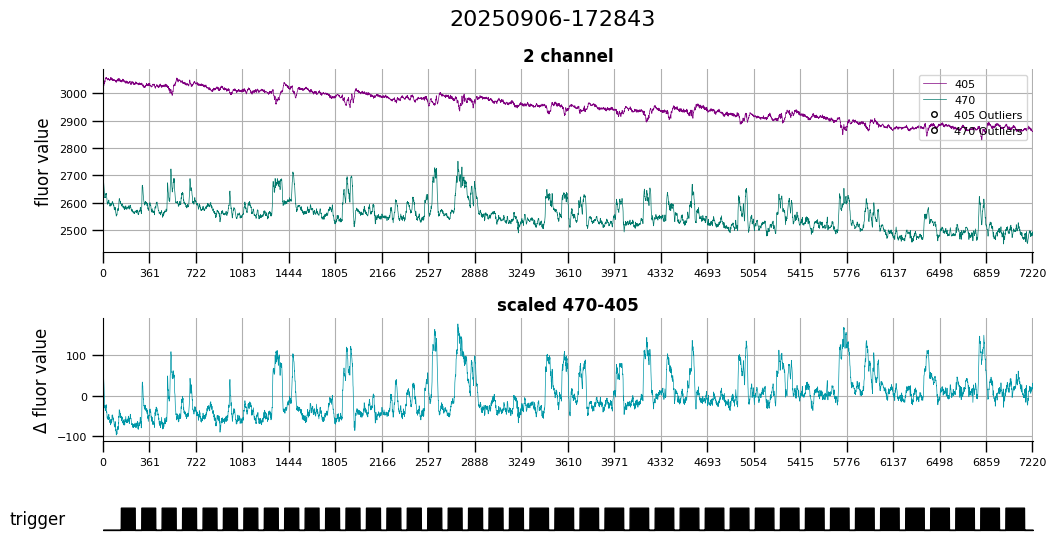

Merged 20250906-170440 already exists


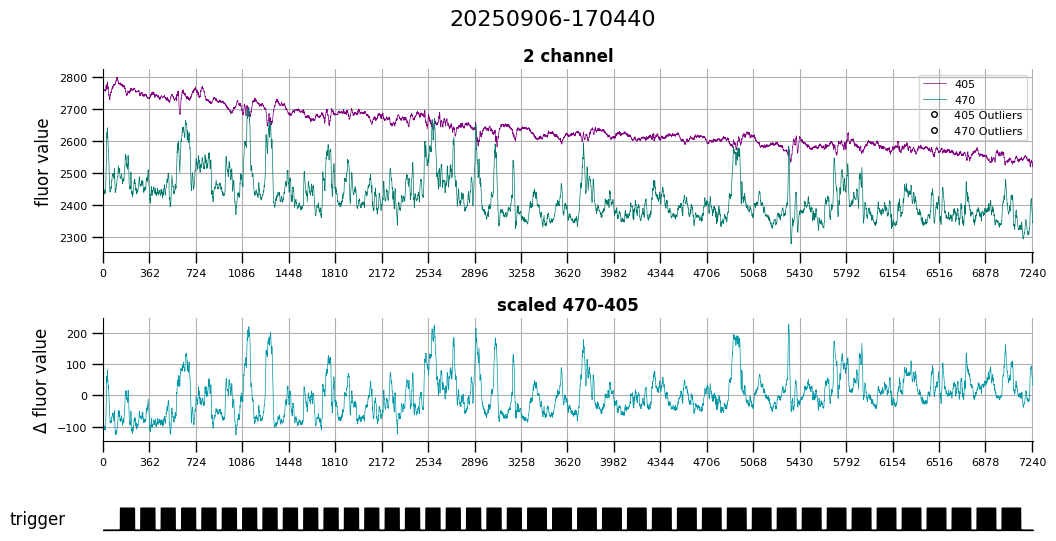

Finished merging for single day.


In [3]:
%matplotlib inline
def filename2int(filename):
    import re
    nums = re.findall(r'\d+', filename)
    return int(nums[-1]) if nums else -1

def organize_tif(folder_path, processPath):
    folder_name = os.path.basename(folder_path)
    tif_path = folder_path + '.tif'
    if os.path.exists(tif_path):
        print(f'importing {tif_path}')
        image_stack = imread(tif_path)
        print(f'finish importing {tif_path}')
    else:
        image_path_ls = glob(os.path.join(folder_path, '*.tif'))
        image_path_ls = sorted(image_path_ls, key=filename2int)
        image_stack = [imread(tiff) for tiff in image_path_ls]
    mean_values = [np.mean(frame) for frame in image_stack]
    output_value = os.path.join(processPath, folder_name + "-Values.csv")
    np.savetxt(output_value, mean_values, delimiter=",")
    return np.array(image_stack)

def merge_two_channels(rawPath, processPath, experiment):
    os.makedirs(os.path.join(processPath, experiment + "-wfield"), exist_ok=True)
    mergePath = os.path.join(processPath, experiment + "-wfield")
    merge_file = os.path.join(mergePath, experiment + "-merged.tif")
    if not os.path.exists(merge_file):
        tif_405 = organize_tif(os.path.join(rawPath, experiment + "-405"), processPath)
        tif_470 = organize_tif(os.path.join(rawPath, experiment + "-470"), processPath)
        print(tif_405.shape[0], tif_470.shape[0])

        if tif_405.shape[0] != tif_470.shape[0]:
            n_frames = min(tif_405.shape[0], tif_470.shape[0])
            tif_405 = tif_405[:n_frames]
            tif_470 = tif_470[:n_frames]
        merged_tif = np.concatenate((tif_470[:, np.newaxis], tif_405[:, np.newaxis]), axis=1)
        imwrite(merge_file, merged_tif, imagej=True, bigtiff=True)
        print(f"Merged file saved: {merge_file}")
    else:
        print(f"Merged {experiment} already exists")

        import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
from tifffile import imread

# def plotFluor(path, experiment):
#     merged_file = os.path.join(path, experiment + '-wfield', experiment + '-merged.tif')
#     print("loading file:", merged_file)
#     stack = imread(merged_file)  # shape: (T, 2, H, W)
#     if stack.ndim == 4 and stack.shape[1] == 2:
#         fluor_470 = stack[:, 0, :, :]  # 通道0是470
#         mean_trace = fluor_470.mean(axis=(1, 2))  # 每帧的平均值
        
#         plt.figure(figsize=(8, 4))
#         plt.plot(mean_trace, label='470 mean F')
#         plt.xlabel('Frame')
#         plt.ylabel('Mean Fluorescence')
#         plt.title(f'{experiment}: 470通道平均荧光')
#         plt.legend()
#         plt.tight_layout()
#         plt.show()
#     else:
#         print("Stack format error or missing channels.")


# ========== 主流程 ==========

single_day_path = "/home/lsh/Data_attention/Transfer learning/DATA_linshu/2-photon/N027/retino"
rawPath = single_day_path
processPath = os.path.join(single_day_path, "process")

items = glob(os.path.join(rawPath, '202?????-??????-4*'))
experiments = list(set([os.path.basename(item)[:15] for item in items]))
print("Experiments found:", experiments)

for experiment in experiments:
    mergePath = os.path.join(processPath, experiment + "-wfield")
    merge_two_channels(rawPath, processPath, experiment)
    plotFluor(single_day_path, experiment)
    
print("Finished merging for single day.")

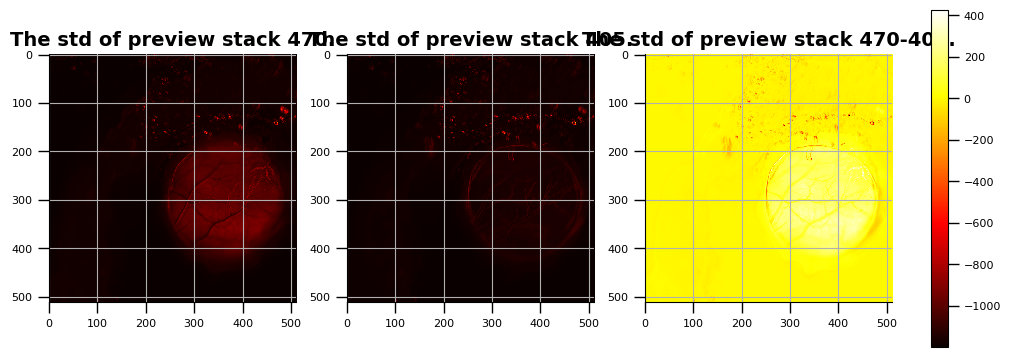

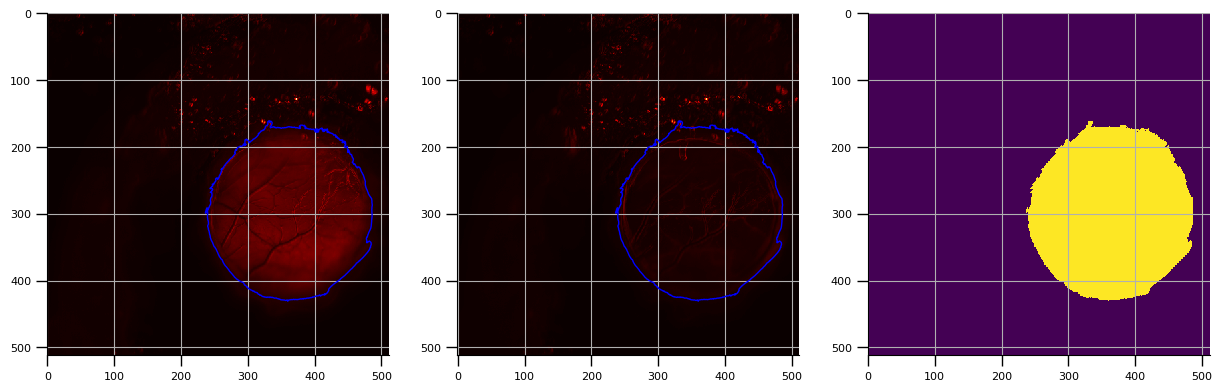

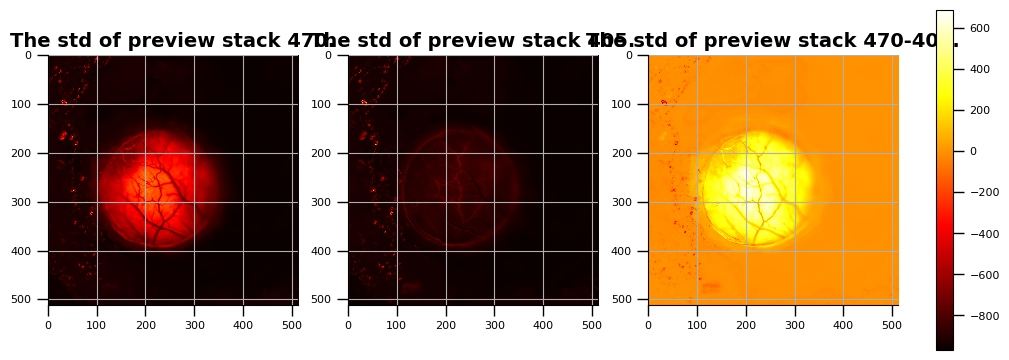

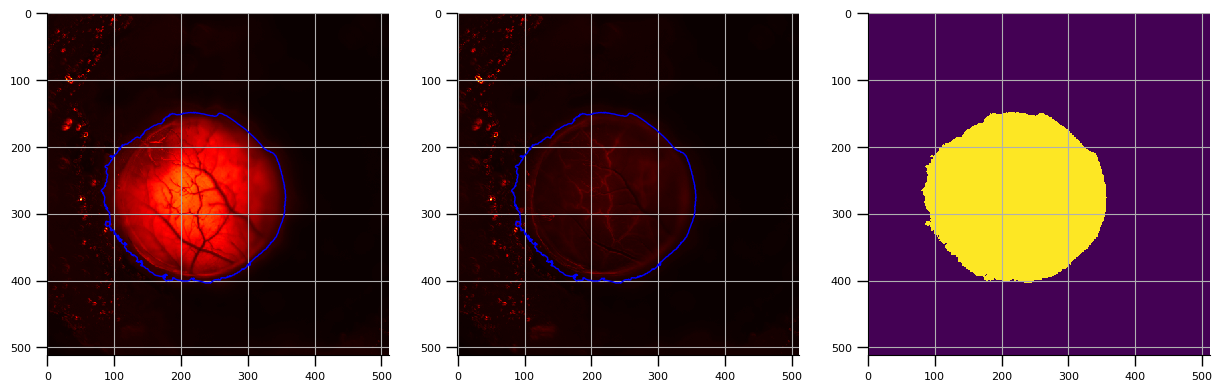

In [4]:
def show_images(images, titles=None, cmap='hot', colorbar=True):
    """
    Display a list of images side by side with a shared colorbar.

    Parameters:
    - images: list of 2D numpy arrays (images to display)
    - titles: list of strings (titles for each image)
    - cmap: string (colormap to use)
    - colorbar: bool (whether to display shared colorbar)
    """
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(10, 4.5), constrained_layout=True)

    # 保证 axes 是可迭代的
    if n == 1:
        axes = [axes]

    # 显示图像并收集每个im对象
    im_objs = []
    for i in range(n):
        im = axes[i].imshow(images[i], cmap=cmap, aspect='equal')
        im_objs.append(im)
        if titles:
            axes[i].set_title(titles[i])
        axes[i].axis('on')  # 不显示坐标轴
        axes[i].grid()

    # 添加共享 colorbar（以最后一个im对象为准）
    if colorbar:
        fig.colorbar(im_objs[-1], ax=axes, orientation='vertical', fraction=0.02, pad=0.04)

    plt.show()

for experiment in experiments:    

    plot_test = True

    n_preview = 600
    tiff_list_470 = glob(pjoin(single_day_path, experiment + '*-470/*.tif'))[:n_preview]
    preview_stack_470 = np.array([imread(tiff) for tiff in tiff_list_470])
    tiff_list_405 = glob(pjoin(single_day_path, experiment + '*-405/*.tif'))[:n_preview]
    preview_stack_405 = np.array([imread(tiff) for tiff in tiff_list_405])
    preview_std_470 = np.std(preview_stack_470, axis=0)
    preview_std_405 = np.std(preview_stack_405, axis=0)

    if plot_test:
        images = [preview_std_470, preview_std_405, preview_std_470 - preview_std_405]
        title = ['The std of preview stack 470.', 
                'The std of preview stack 405.', 
                'The std of preview stack 470-405.']
        show_images(images, titles=title, colorbar=True)
        std_level = 100

    contour = measure.find_contours(image=preview_std_470, level=std_level)
    contour_len = [len(_contour) for _contour in contour]
    contour_max = contour[np.argmax(contour_len)]

    mask = np.zeros_like(preview_std_470)
    mask_edge = np.flip(contour_max, axis=1).astype(int)
    mask = cv2.fillPoly(mask, [mask_edge], 1)
    mergePath = os.path.join(processPath, experiment + "-wfield")
    save_path = os.path.join(mergePath, "mask.npy")
    np.save(save_path, mask)


    if plot_test:
        fig, axis = plt.subplots(figsize=(15, 5), nrows=1, ncols=3)
        
        axis[0].imshow(preview_std_470, cmap='hot')
        axis[0].plot(contour_max[:, 1], contour_max[:, 0], linewidth=1, color='blue')
        axis[0].grid()
        axis[1].imshow(preview_std_405, cmap='hot')
        axis[1].plot(contour_max[:, 1], contour_max[:, 0], linewidth=1, color='blue')
        axis[1].grid()
        axis[2].imshow(mask)
        axis[2].grid()
        plt.show()

In [5]:
for experiment in experiments:
    mergePath = os.path.join(processPath, experiment + "-wfield")  
    print(mergePath)
    _ls = os.listdir(mergePath)

    for f in _ls:
        if f.endswith('.bin'):
            old_bin = os.path.join(mergePath, f)
            os.remove(old_bin)
            print(f'>>> Removed old bin file: {old_bin}')
    
    if np.array([_.endswith('.tif') for _ in _ls]).sum() > 1:
        print('!!! There are more than one tif files in the folder, please check the folder!')
    
    tif_stack =  imread(pjoin(mergePath,'*-merged.tif')) 
    tif_stack = tif_stack.astype(np.uint16)# set nchannels=1 for our 2 channel tif file

    mask_path = os.path.join(mergePath, "mask.npy")
    mask = np.load(mask_path)
    masked_stack = tif_stack * mask[None, None, :, :]

    masked_stack = masked_stack.astype(np.uint16)# set nchannels=1 for our 2 channel tif file
    print(masked_stack.shape)
    print('The frames of the stack:', masked_stack.shape[0])
    if masked_stack.shape[0] == 0:
        print('The shape of the stack may be wrong!')

    else: 
        bin_path = pjoin(mergePath, f"{masked_stack.shape[0]}_{masked_stack.shape[1]}_{masked_stack.shape[2]}_{masked_stack.shape[3]}_masked_uint16.bin")
        os.makedirs(os.path.dirname(bin_path), exist_ok=True)
        masked_stack.tofile(bin_path)
        print('Binary file saved:', bin_path)
        
    
print('finish generate binary file.')

/home/lsh/Data_attention/Transfer learning/DATA_linshu/2-photon/N027/retino/process/20250906-172843-wfield
(7224, 2, 512, 512)
The frames of the stack: 7224
Binary file saved: /home/lsh/Data_attention/Transfer learning/DATA_linshu/2-photon/N027/retino/process/20250906-172843-wfield/7224_2_512_512_masked_uint16.bin
/home/lsh/Data_attention/Transfer learning/DATA_linshu/2-photon/N027/retino/process/20250906-170440-wfield
>>> Removed old bin file: /home/lsh/Data_attention/Transfer learning/DATA_linshu/2-photon/N027/retino/process/20250906-170440-wfield/7249_2_512_512_masked_uint16.bin
(7249, 2, 512, 512)
The frames of the stack: 7249
Binary file saved: /home/lsh/Data_attention/Transfer learning/DATA_linshu/2-photon/N027/retino/process/20250906-170440-wfield/7249_2_512_512_masked_uint16.bin
finish generate binary file.


['/home/lsh/Data_attention/Transfer learning/DATA_linshu/2-photon/N027/retino/process/20250906-172843-wfield/7224_2_512_512_masked_uint16.bin']


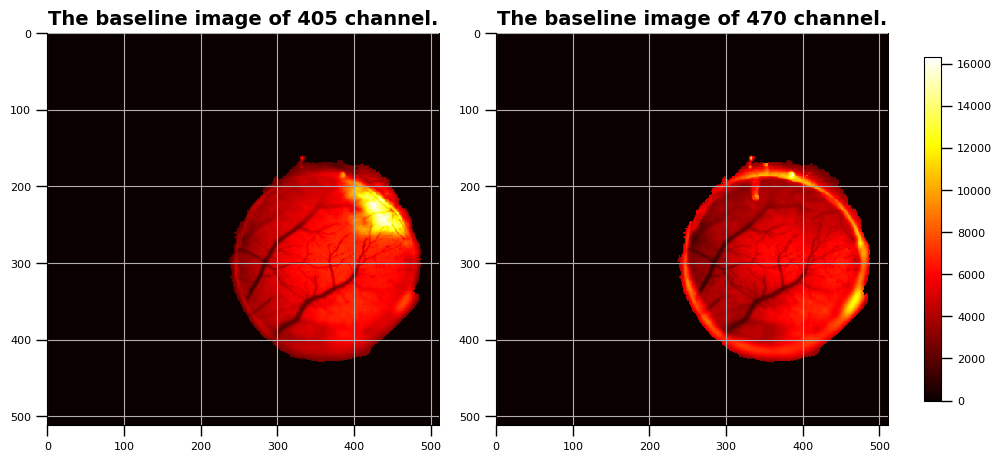

Computing SVT from the raw data: 100%|██████████| 15/15 [00:14<00:00,  1.01it/s]


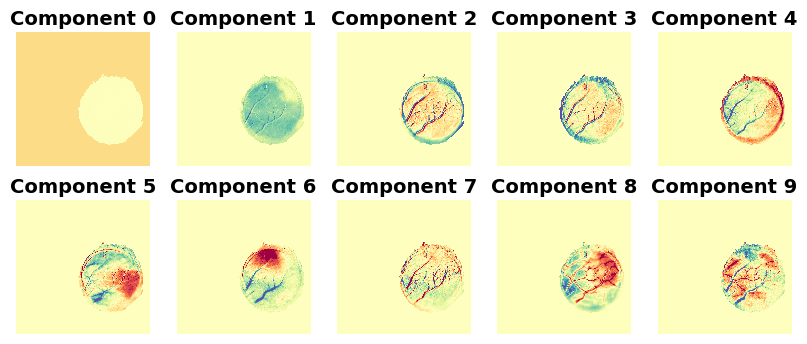

['/home/lsh/Data_attention/Transfer learning/DATA_linshu/2-photon/N027/retino/process/20250906-170440-wfield/7249_2_512_512_masked_uint16.bin']


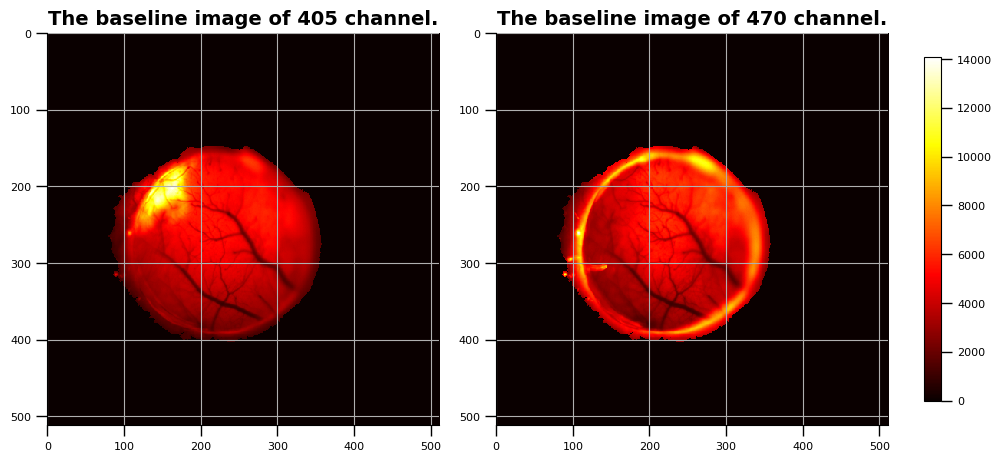

Computing SVT from the raw data: 100%|██████████| 15/15 [00:35<00:00,  2.39s/it]


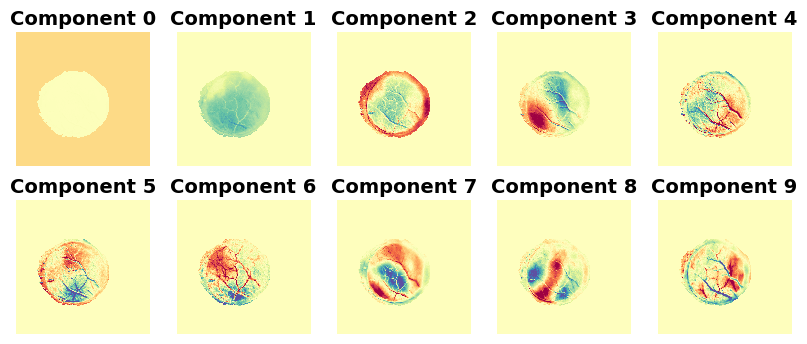

In [ ]:
for experiment in experiments:
    mergePath = os.path.join(processPath, experiment + "-wfield")    
    print(glob(pjoin(mergePath, '*uint16.bin')))
    dat = mmap_dat(glob(pjoin(mergePath, '*uint16.bin'))[0])
    image_base_min = np.min(dat[-300:, :, :, :], axis=0)
    np.save(pjoin(mergePath, 'frames_average.npy'), image_base_min)

    if plot_test:
        images = [image_base_min[0], image_base_min[1]]
        title = ['The baseline image of 405 channel.', 'The baseline image of 470 channel.']
        show_images(images, titles=title, colorbar=True)
    
    U, SVT = approximate_svd(dat, image_base_min)

    np.save(pjoin(mergePath,'U.npy'), U)
    np.save(pjoin(mergePath,'SVT.npy'), SVT)

    if plot_test:
        ncomponents = 10
        ncols = 5
        nrows = int(np.ceil(ncomponents/ncols))
        fig = plt.figure(figsize=[2*ncols, 2*nrows])
        for icomponent in range(ncomponents):
            fig.add_subplot(nrows, ncols, icomponent+1)
            plt.imshow(U[:, :, icomponent], clim=[-0.01,0.01],cmap='Spectral_r')
            plt.title('Component {}'.format(icomponent))
            plt.axis('off')
        plt.show()
        
    tstart = time.time()
    fs = 10
    freq_highpass = 0.001
    SVT_470 = SVT[:,0::2]
    t = np.arange(SVT.shape[1]) # interpolate the violet
    from scipy.interpolate import interp1d
    SVT_405 = interp1d(t[1::2], SVT[:,1::2], axis=1,
                        fill_value='extrapolate')(t[0::2])
    # SVTcorr, rcoeffs, T = hemodynamic_correction(U, 
    #                                              SVT_470, 
    #                                              SVT_405, 
    #                                              fs=fs,
    #                                              freq_highpass=freq_highpass,
    #                                              freq_lowpass=10)  

    print('Done hemodynamic correction in {0} s '.format(time.time()-tstart))
    SVTcorr = SVT_470 - SVT_405

    # np.save(pjoin(path,'rcoeffs.npy'), rcoeffs)
    # np.save(pjoin(path,'T.npy'),T)
    np.save(pjoin(wfield_path,'SVTcorr.npy'), SVTcorr)
